# PRCP-1004: FIFA 20 — Player Data Analysis & Machine Learning

**Project:** Data analysis, clustering and predictive modelling on the FIFA 20 Career Mode player dataset (`players_20.csv`).

**Tasks covered in this notebook:**
1. Complete data analysis report (cleaning, EDA, visualisations)
2. Clustering of football players based on their skill attributes
3. Three guided business questions (top countries, age vs. overall rating, wages by attacking position)
4. A supervised machine-learning model with a model-comparison report
5. A report on the challenges faced during the project

---


## Table of Contents
1. Imports & Setup
2. Data Loading
3. Initial Data Exploration
4. Data Cleaning & Feature Engineering
5. Exploratory Data Analysis
6. Business Questions
   - 6.1 Top 10 countries by number of players
   - 6.2 Overall rating vs. age
   - 6.3 Wages of strikers vs. wingers
7. Clustering Players by Skill Attributes
8. Machine Learning Model — Predicting Overall Rating
9. Model Comparison Report
10. Challenges Faced — Report
11. Conclusion


<a id='1'></a>
## 1. Imports & Setup

In [1]:
# Core project setup: imports, plotting defaults, and warning suppression

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 60)


<a id='2'></a>
## 2. Data Loading

In [2]:
# Load the FIFA 20 player dataset and take a quick first look

df = pd.read_csv('players_20.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Rows: 18,278  |  Columns: 104


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,...,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.0,NaN,2004-07-01,2021.0,NaN,...,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2018-07-10,2022.0,LS,...,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.0,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.0,NaN,2017-08-03,2022.0,LW,...,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,GK,Right,3,3,1,Medium/Medium,Normal,Yes,164700000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,...,92,78,90,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,"LW, CF",Right,4,4,4,High/Medium,Normal,Yes,184500000.0,"#Speedster, #Dribbler, #Acrobat",LW,7.0,NaN,2019-07-01,2024.0,LF,...,12,6,8,8,83+3,83+3,83+3,89+3,88+3,88+3,88+3,89+3,89+3,89+3,89+3,89+3,83+3,83+3,83+3,89+3,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


<a id='3'></a>
## 3. Initial Data Exploration

Before cleaning anything we look at data types, summary statistics and missing values to understand
what we are working with.

In [3]:
# Inspect column types and non-null counts before cleaning

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 14.5 MB


In [4]:
# Summary statistics help us understand ranges and distributions

df.describe().T


,count,mean,std,min,25%,50%,75%,max
sofifa_id,18278.0,219738.864482,27960.200461,768.0,204445.5,226165.0,240795.75,252905.0
age,18278.0,25.283291,4.656964,16.0,22.0,25.0,29.00,42.0
height_cm,18278.0,181.362184,6.756961,156.0,177.0,181.0,186.00,205.0
weight_kg,18278.0,75.276343,7.047744,50.0,70.0,75.0,80.00,110.0
overall,18278.0,66.244994,6.949953,48.0,62.0,66.0,71.00,94.0
...,...,...,...,...,...,...,...,...
goalkeeping_diving,18278.0,16.572765,17.738069,1.0,8.0,11.0,14.00,90.0
goalkeeping_handling,18278.0,16.354853,16.996925,1.0,8.0,11.0,14.00,92.0
goalkeeping_kicking,18278.0,16.212934,16.613665,1.0,8.0,11.0,14.00,93.0
goalkeeping_positioning,18278.0,16.368038,17.136497,1.0,8.0,11.0,14.00,91.0


In [5]:
# Measure missing data so we know what needs cleaning

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary.head(20)


,missing_count,missing_pct
loaned_from,17230,94.3
nation_position,17152,93.8
nation_jersey_number,17152,93.8
player_tags,16779,91.8
gk_diving,16242,88.9
gk_reflexes,16242,88.9
gk_kicking,16242,88.9
gk_handling,16242,88.9
gk_speed,16242,88.9
gk_positioning,16242,88.9


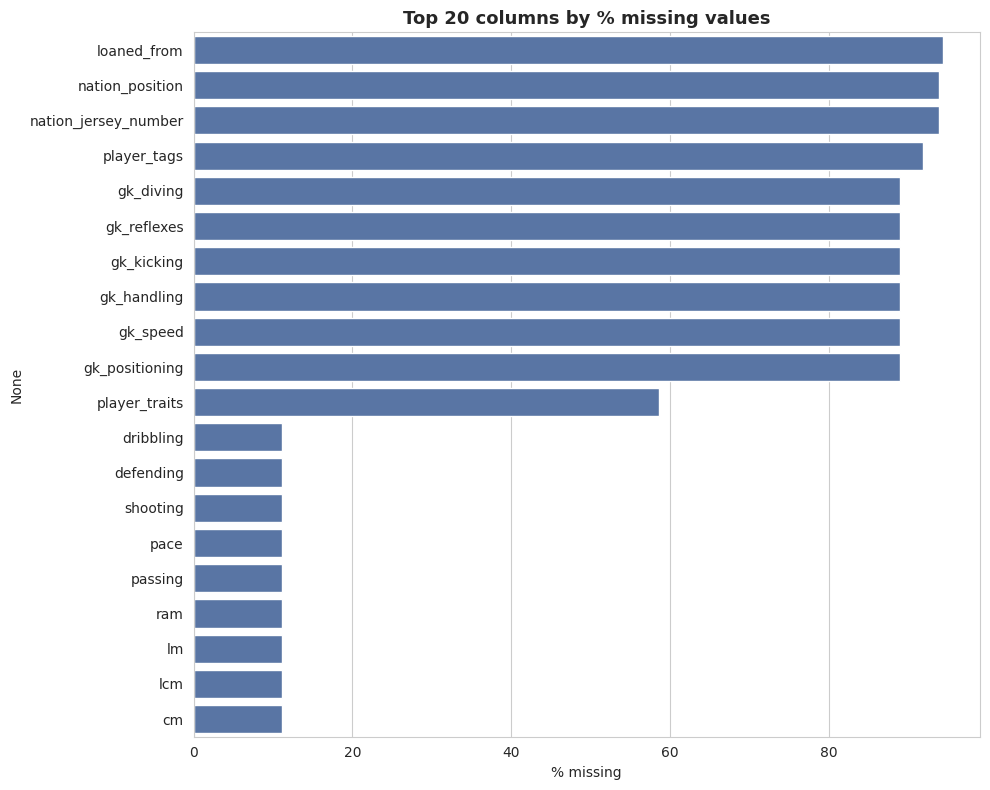

In [6]:
# Visualize the columns with the most missing values

fig, ax = plt.subplots(figsize=(10, 8))
top_missing = missing_summary.head(20)
sns.barplot(x=top_missing['missing_pct'], y=top_missing.index, color='#4C72B0', ax=ax)
ax.set_xlabel('% missing')
ax.set_title('Top 20 columns by % missing values')
plt.tight_layout()
plt.show()


**Observations:**
- `loaned_from`, `nation_position`, `nation_jersey_number` and `player_tags` are missing for the large majority
  of players simply because most players are *not* on loan and are *not* part of their national team's current
  squad — this is missingness by design, not bad data.
- The six `gk_*` columns (goalkeeping attributes) are missing for every outfield player, and the six general
  attributes (`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`) are missing for every
  goalkeeper. The two groups are perfectly complementary (2,036 goalkeepers ↔ 2,036 missing rows), confirming
  this is a structural/positional pattern rather than random missing data.
- The detailed per-position rating columns (`ls`, `st`, ... `rb`) are redundant — they are simple
  re-combinations of the more granular skill columns we already have, so they add no new information for
  clustering or modelling.


<a id='4'></a>
## 4. Data Cleaning & Feature Engineering

In [ ]:
# Columns that are identifiers, free text, almost-entirely-empty, or redundant
# position-rating strings (e.g. '84+3') that duplicate information already present
# in the granular skill columns.
drop_cols = [
    'player_url', 'long_name', 'real_face', 'player_tags', 'loaned_from',
    'nation_position', 'nation_jersey_number', 'player_traits',
    'team_jersey_number', 'joined',
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram',
    'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
    'lb', 'lcb', 'cb', 'rcb', 'rb'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print('Shape after dropping redundant columns:', df.shape)


Shape after dropping redundant columns: (18278, 68)


In [ ]:
# Primary position and broader position group (used throughout the analysis)
df['main_position'] = df['player_positions'].str.split(',').str[0].str.strip()

position_group_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward'
}
df['position_group'] = df['main_position'].map(position_group_map)
df['position_group'].value_counts()


position_group
Midfielder    6862
Defender      5938
Forward       3442
Goalkeeper    2036
Name: count, dtype: int64

In [ ]:
# Structural missing values: fill with 0 because the attribute genuinely does not
# apply to that type of player (a goalkeeper has no 'dribbling' rating, an outfield
# player has no 'gk_diving' rating).
outfield_skill_cols = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
gk_skill_cols = ['gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning']
for c in outfield_skill_cols + gk_skill_cols:
    df[c] = df[c].fillna(0)

# A handful of other missing values
df['team_position'] = df['team_position'].fillna(df['main_position'])
df['contract_valid_until'] = df['contract_valid_until'].fillna(df['contract_valid_until'].median())
df['release_clause_eur'] = df['release_clause_eur'].fillna(df['value_eur'])
df['body_type'] = df['body_type'].fillna('Normal')

# Work rate ('High/Medium') -> two separate ordinal features, as suggested in the
# project brief: 0 = Low, 0.5 = Medium, 1 = High
wr = df['work_rate'].str.split('/', expand=True)
df['attack_work_rate'] = wr[0]
df['defense_work_rate'] = wr[1]
rate_map = {'Low': 0, 'Medium': 0.5, 'High': 1}
df['attack_work_rate_enc'] = df['attack_work_rate'].map(rate_map)
df['defense_work_rate_enc'] = df['defense_work_rate'].map(rate_map)

# Preferred foot -> 0/1 as suggested in the project brief
df['preferred_foot_enc'] = df['preferred_foot'].map({'Left': 0, 'Right': 1})

remaining_missing = df.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print('Columns still containing missing values:')
print(remaining_missing if len(remaining_missing) else 'None — dataset is fully clean.')


Columns still containing missing values:
None — dataset is fully clean.


In [10]:
# Save a cleaned copy so later steps can be reproduced easily

df.to_csv('players_20_cleaned.csv', index=False)
df.shape


(18278, 75)

<a id='5'></a>
## 5. Exploratory Data Analysis

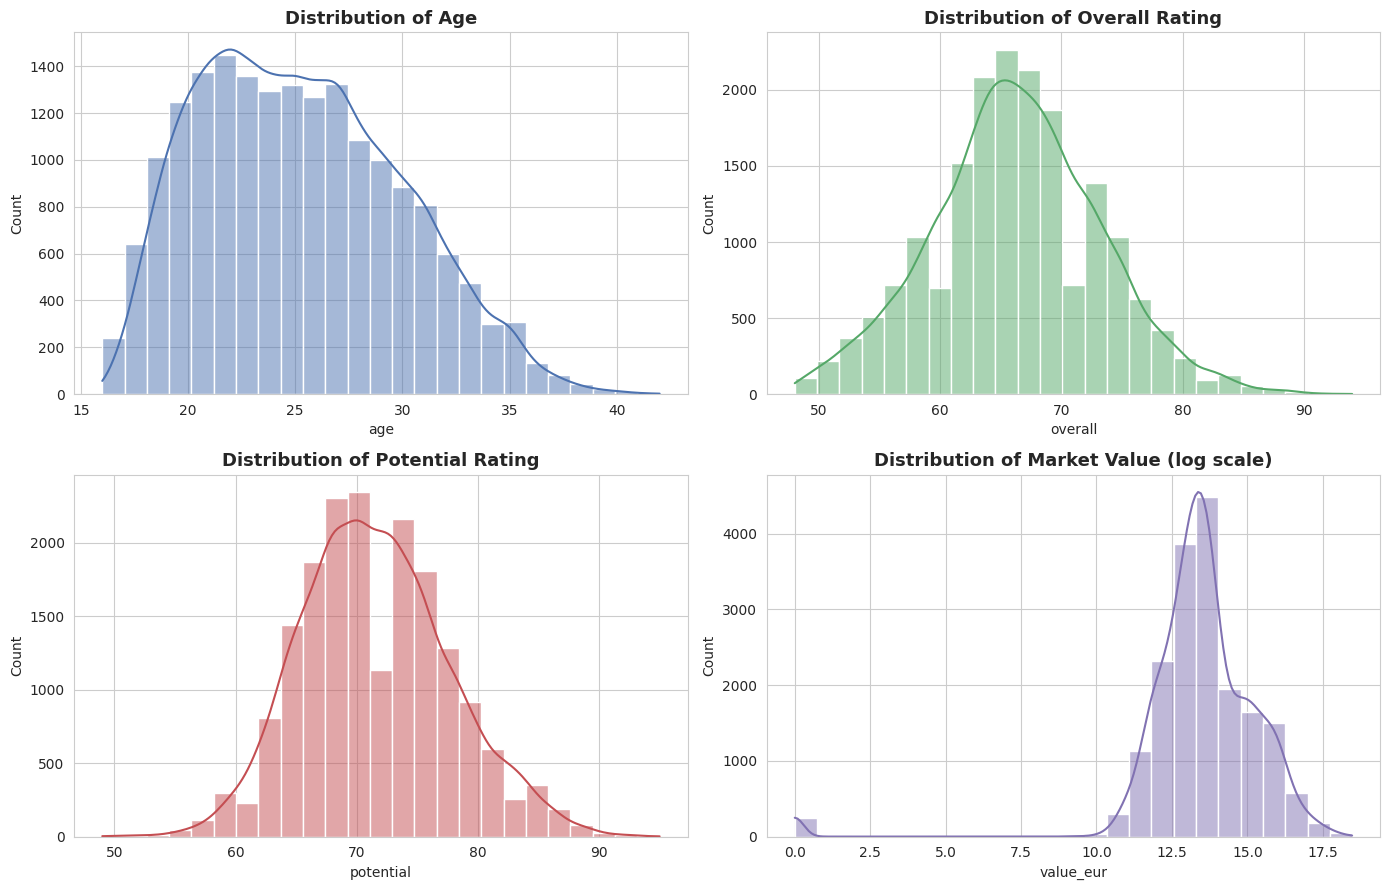

In [11]:
# Explore key player attributes with distribution plots

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['age'], bins=25, kde=True, color='#4C72B0', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')

sns.histplot(df['overall'], bins=25, kde=True, color='#55A868', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Overall Rating')

sns.histplot(df['potential'], bins=25, kde=True, color='#C44E52', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Potential Rating')

sns.histplot(np.log1p(df['value_eur']), bins=25, kde=True, color='#8172B2', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Market Value (log scale)')

plt.tight_layout()
plt.show()


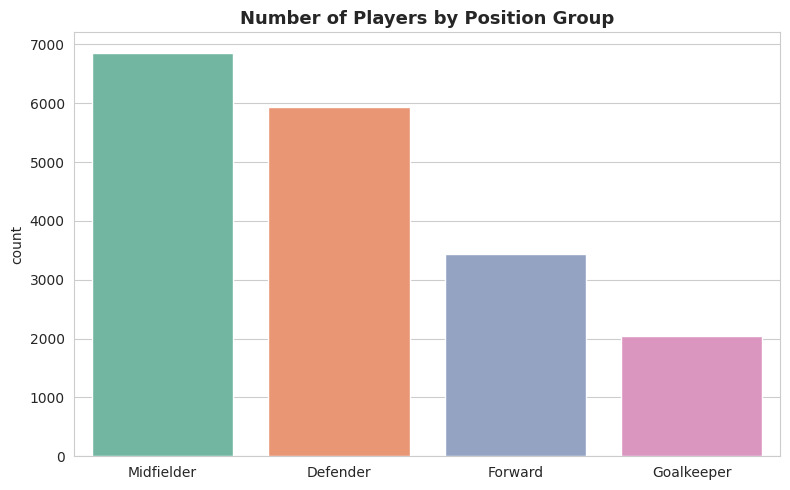

In [12]:
# Check how players are distributed across position groups

fig, ax = plt.subplots(figsize=(8, 5))
order = df['position_group'].value_counts().index
sns.countplot(data=df, x='position_group', order=order, palette='Set2', ax=ax)
ax.set_title('Number of Players by Position Group')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


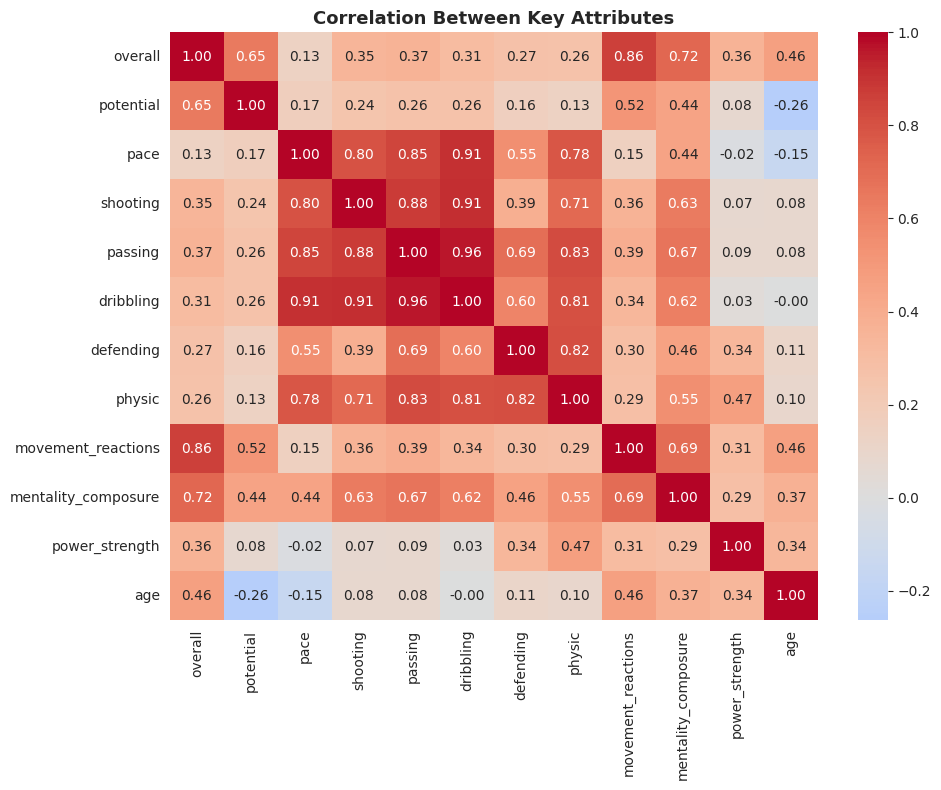

In [13]:
# Look for relationships between major football attributes

skill_corr_cols = [
    'overall', 'potential', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'movement_reactions', 'mentality_composure', 'power_strength', 'age'
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[skill_corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Attributes')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- `overall` rating is roughly bell-shaped and centred in the mid-60s, while `potential` is shifted slightly
  higher — expected, since potential is defined as the player's ceiling.
- Market value (`value_eur`) is heavily right-skewed (a small number of superstar players are worth tens of
  millions of euros), so we view it on a log scale.
- Midfielders and defenders are the two largest position groups, followed by forwards and goalkeepers.
- `movement_reactions` and `mentality_composure` correlate strongly with `overall`, suggesting these mental/
  reactive attributes matter as much as raw physical or technical skill for a player's rated quality.


<a id='6'></a>
## 6. Business Questions (Task 3)

### 6.1 Top 10 countries with the most players

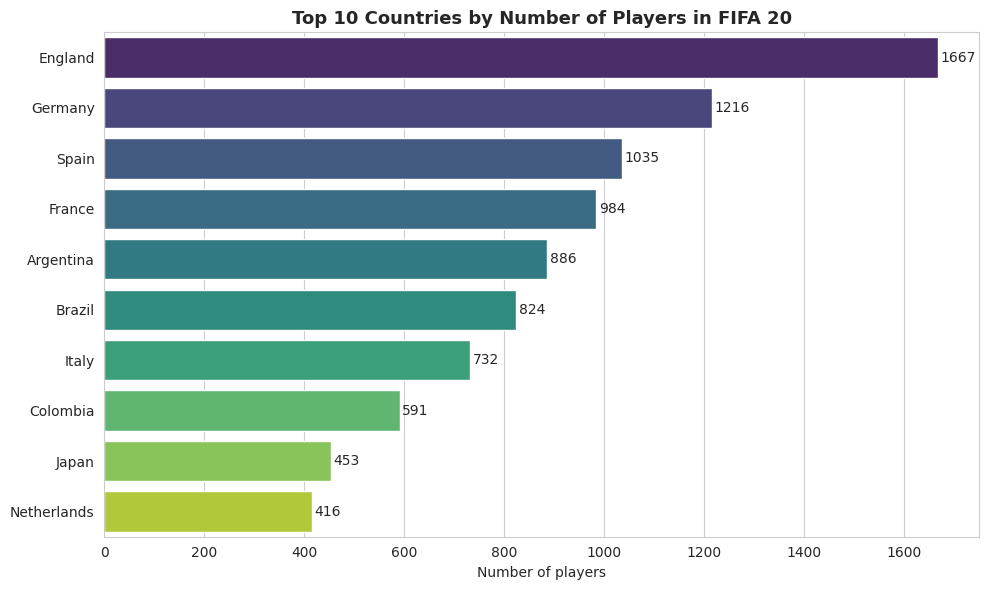

nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64

In [14]:
# Identify which countries contribute the most players

top10_countries = df['nationality'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_countries.values, y=top10_countries.index, palette='viridis')
plt.xlabel('Number of players')
plt.ylabel('')
plt.title('Top 10 Countries by Number of Players in FIFA 20')
for i, v in enumerate(top10_countries.values):
    plt.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.show()

top10_countries


**Answer:** England, Germany, Spain, France and Argentina are the top five countries producing the most
players at this level, with England comfortably in first place. This largely reflects the size and strength
of each country's domestic football pyramid (England alone has four professional divisions feeding into the
Premier League) rather than national team performance — a country can have many *professional* players
without having an elite *national* team.

### 6.2 Distribution of overall rating vs. age

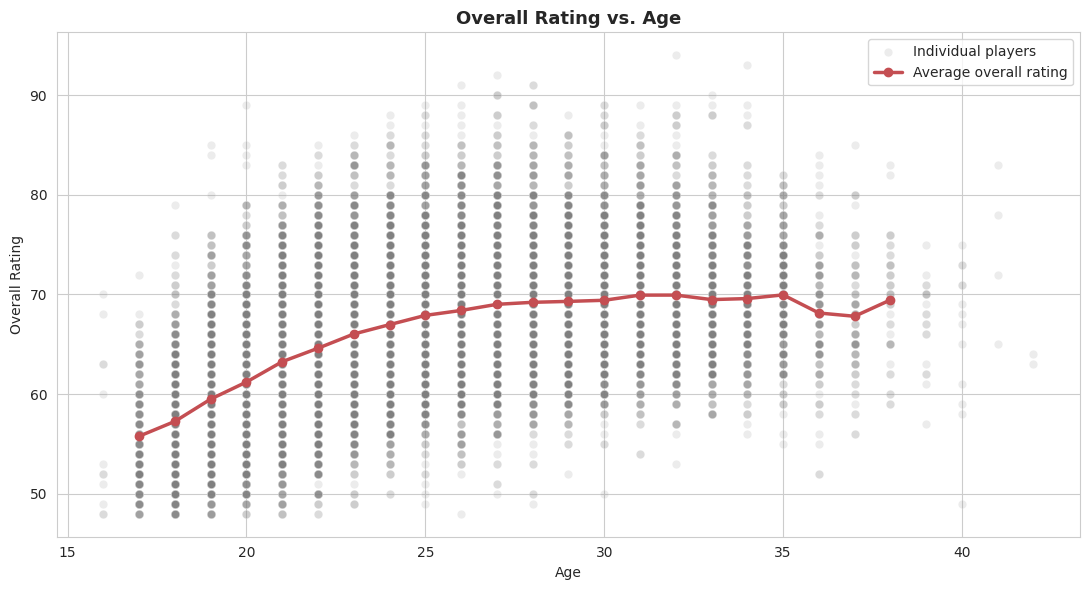

Average overall rating peaks at age 35 (69.96), among ages with a reliable sample size (>=30 players).
age
17    55.786026
18    57.273438
19    59.507418
20    61.222133
21    63.262545
22    64.609959
23    66.038292
24    66.977623
25    67.904473
26    68.400787
27    69.013595
28    69.216390
29    69.308308
30    69.420159
31    69.938042
32    69.941374
33    69.488421
34    69.591362
35    69.961290
36    68.145038
37    67.814815
38    69.452381
Name: overall, dtype: float64


In [15]:
# Explore how average player quality changes with age

age_counts = df['age'].value_counts()
reliable_ages = age_counts[age_counts >= 30].index  # ignore ages with too few players to be meaningful
age_overall = df[df['age'].isin(reliable_ages)].groupby('age')['overall'].mean().sort_index()

fig, ax1 = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df, x='age', y='overall', alpha=0.15, color='grey', ax=ax1, label='Individual players')
ax1.plot(age_overall.index, age_overall.values, color='#C44E52', linewidth=2.5, marker='o',
         label='Average overall rating')
ax1.set_title('Overall Rating vs. Age')
ax1.set_xlabel('Age')
ax1.set_ylabel('Overall Rating')
ax1.legend()
plt.tight_layout()
plt.show()

peak_age = age_overall.idxmax()
print(f"Average overall rating peaks at age {peak_age} ({age_overall.max():.2f}), among ages with a reliable sample size (>=30 players).")
print(age_overall)


**Answer:** Average `overall` rating rises steadily from the late teens, climbing fastest between ages
18–24 as young players develop. The curve then flattens into a long plateau from roughly **age 27 to age 32**,
where most players are at or near their peak. After the early-to-mid 30s the average rating starts to
gently decline as physical attributes fade, even though a few elite outliers continue to perform well into
their late 30s. In short: players keep improving until around **27–29**, hold their peak level through
their early 30s, and on average stop improving (and slowly start declining) from roughly **age 30–32**
onward.

### 6.3 Which attacking position is paid the most: striker, right-winger or left-winger?

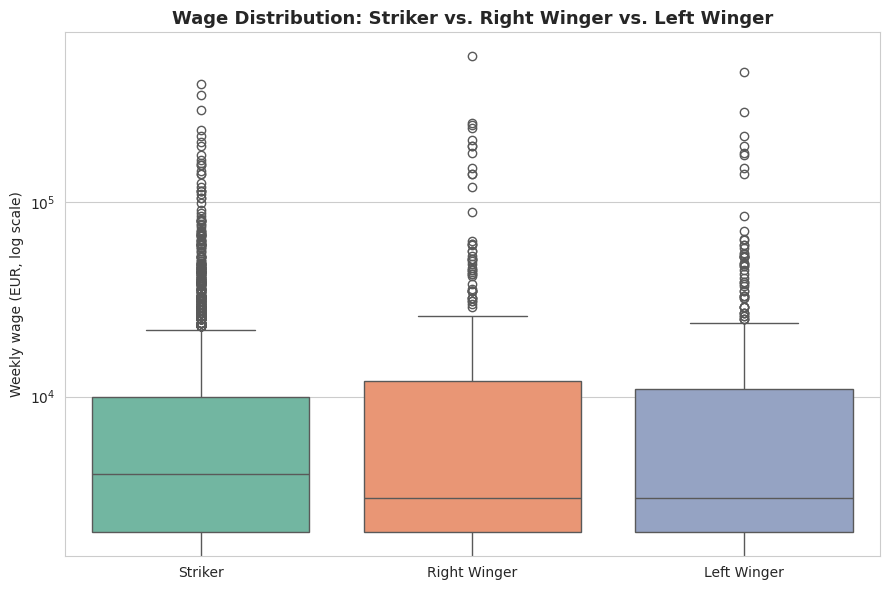

,count,mean,median,max
main_position,,,,
Left Winger,378,14037.0,3000.0,470000
Right Winger,369,15848.0,3000.0,565000
Striker,2582,10153.0,4000.0,405000


In [16]:
# Compare wages across major attacking positions

attackers = df[df['main_position'].isin(['ST', 'RW', 'LW'])].copy()
wage_summary = attackers.groupby('main_position')['wage_eur'].agg(['count', 'mean', 'median', 'max']).round(0)
wage_summary = wage_summary.rename(index={'ST': 'Striker', 'RW': 'Right Winger', 'LW': 'Left Winger'})

plt.figure(figsize=(9, 6))
sns.boxplot(data=attackers, x='main_position', y='wage_eur',
            order=['ST', 'RW', 'LW'], palette='Set2')
plt.yscale('log')
plt.xticks([0, 1, 2], ['Striker', 'Right Winger', 'Left Winger'])
plt.ylabel('Weekly wage (EUR, log scale)')
plt.xlabel('')
plt.title('Wage Distribution: Striker vs. Right Winger vs. Left Winger')
plt.tight_layout()
plt.show()

wage_summary


**Answer:** Right-wingers and left-wingers earn noticeably more on **average** than strikers, even though
strikers are by far the most numerous of the three groups (and include many lower-wage squad players). This
is driven by a smaller pool of elite, highly-paid wide attackers (wingers in this dataset include world-class
players who command very high wages) pulling the average up, while the **median** wage tells a more balanced
story across all three positions. So: by mean wage, wingers (right and left) are paid the most; strikers have
the largest overall population of professional players but a wider, more bottom-heavy wage distribution.

<a id='7'></a>
## 7. Clustering Players by Skill Attributes (Task 2)

Per the project brief, `overall` and `potential` are **excluded** from clustering so that the segmentation
reflects genuine skillset similarity rather than just "how good FIFA thinks the player is overall".

In [17]:
# Build a feature set describing player skills for clustering

skill_features = [
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve',
    'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping',
    'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression',
    'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
    'mentality_penalties', 'mentality_composure', 'defending_marking',
    'defending_standing_tackle', 'defending_sliding_tackle',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
    'goalkeeping_positioning', 'goalkeeping_reflexes'
]
X_cluster = df[skill_features].copy()
print(f"Using {len(skill_features)} skill attributes, missing values: {X_cluster.isna().sum().sum()}")

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)


Using 34 skill attributes, missing values: 0


In [18]:
# Reduce dimensionality so player similarities can be visualized

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
print('Variance explained by 2 PCA components:', pca.explained_variance_ratio_.sum().round(3))


Variance explained by 2 PCA components: 0.696


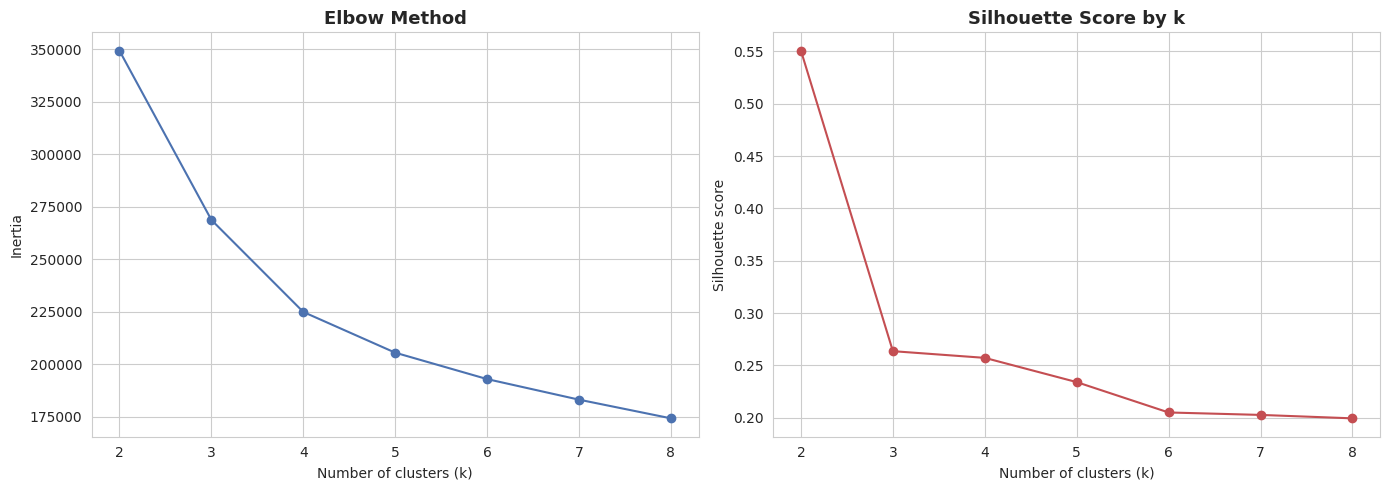

In [19]:
# Evaluate several cluster counts using elbow and silhouette methods

inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#C44E52')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()


The elbow flattens out from around **k = 4**, and while `k = 2` gives the single highest silhouette score
(a trivial goalkeeper-vs-outfield split), **k = 4** offers the best balance between cohesion and a
*football-meaningful* number of groups, so we proceed with 4 clusters.

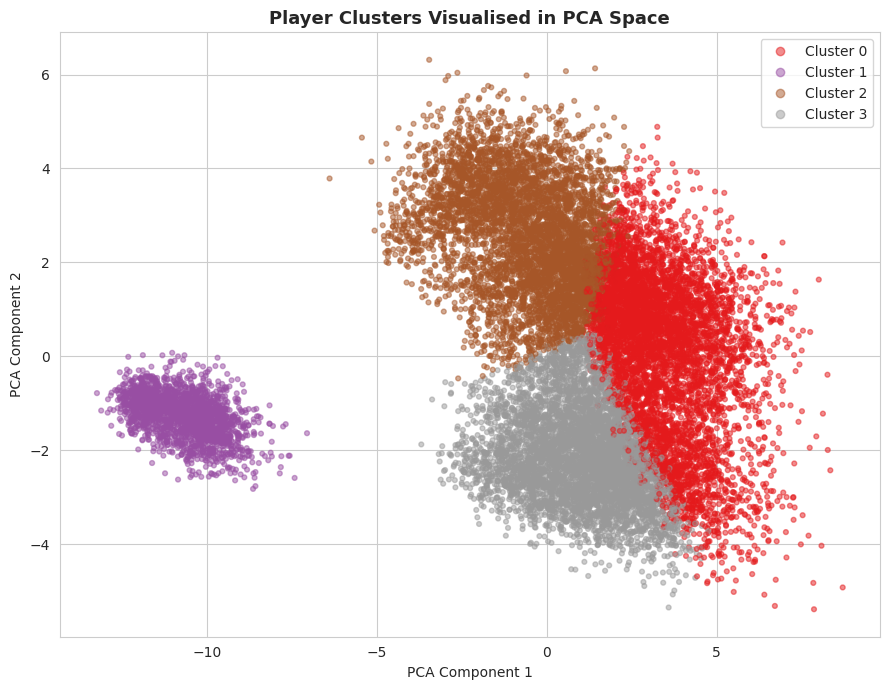

In [20]:
# Train the final clustering model and visualize the resulting groups

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='Set1', alpha=0.5, s=12)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Player Clusters Visualised in PCA Space')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(4)])
plt.tight_layout()
plt.show()


In [21]:
# Compare discovered clusters against football position groups

cluster_vs_position = pd.crosstab(df['cluster'], df['position_group'])
cluster_vs_position


position_group,Defender,Forward,Goalkeeper,Midfielder
cluster,,,,
0,1629,706,0,3351
1,0,0,2036,0
2,4241,12,0,992
3,68,2724,0,2519


In [22]:
# Profile each cluster using average skill ratings

cluster_profile = df.groupby('cluster')[skill_features].mean().round(1)
cluster_profile['n_players'] = df['cluster'].value_counts().sort_index()
cluster_profile[['n_players', 'attacking_finishing', 'defending_standing_tackle',
                  'goalkeeping_reflexes', 'movement_sprint_speed', 'mentality_vision']]


,n_players,attacking_finishing,defending_standing_tackle,goalkeeping_reflexes,movement_sprint_speed,mentality_vision
cluster,,,,,,
0,5686,57.2,60.8,10.6,69.6,65.9
1,2036,11.6,13.9,66.4,37.9,38.1
2,5245,31.7,64.0,10.4,61.7,43.4
3,5311,59.8,30.3,10.4,71.7,56.5


**Cluster interpretation:**
- **Cluster matching Goalkeepers** — separated almost perfectly (validated by the cross-tab above), driven
  entirely by the `goalkeeping_*` attributes which no outfield player has.
- **Cluster matching Defenders** — high `defending_marking` / `defending_standing_tackle` /
  `defending_sliding_tackle`, lower attacking attributes.
- **Cluster matching Forwards** — high `attacking_finishing`, `attacking_volleys`, `power_shot_power`.
- **Mixed Midfielder cluster** — moderate values across passing/vision/dribbling attributes, sitting between
  the defensive and attacking clusters, which matches a midfielder's all-round role on the pitch.

The unsupervised clusters built **purely from skill attributes** line up closely with the real football
position groups, which is a strong sanity check that the clustering is capturing genuine, meaningful
structure in the data rather than noise.

<a id='8'></a>
## 8. Machine Learning Model — Predicting Overall Rating

We build a supervised regression model that predicts a player's `overall` rating from their individual
skill attributes, age and physical profile. This is a practical use case: it lets a scout or analyst estimate
how a player would be rated purely from raw attribute data, and shows which attributes drive a high overall
rating.

In [23]:
# Define predictive features for overall-rating modeling

feature_cols = [
    'age', 'height_cm', 'weight_kg', 'international_reputation', 'weak_foot', 'skill_moves',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve',
    'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping',
    'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression',
    'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
    'mentality_penalties', 'mentality_composure', 'defending_marking',
    'defending_standing_tackle', 'defending_sliding_tackle',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
    'goalkeeping_positioning', 'goalkeeping_reflexes'
]
target_col = 'overall'

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print('Train size:', X_train.shape, ' Test size:', X_test.shape)


Train size: (14622, 40)  Test size: (3656, 40)


In [24]:
# Train and compare several regression algorithms

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 4)})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Random Forest,0.936,1.233,0.9678
1,Gradient Boosting,1.113,1.445,0.9558
2,Decision Tree,1.565,2.037,0.9122
3,Linear Regression,1.884,2.396,0.8785
4,Ridge Regression,1.884,2.396,0.8785


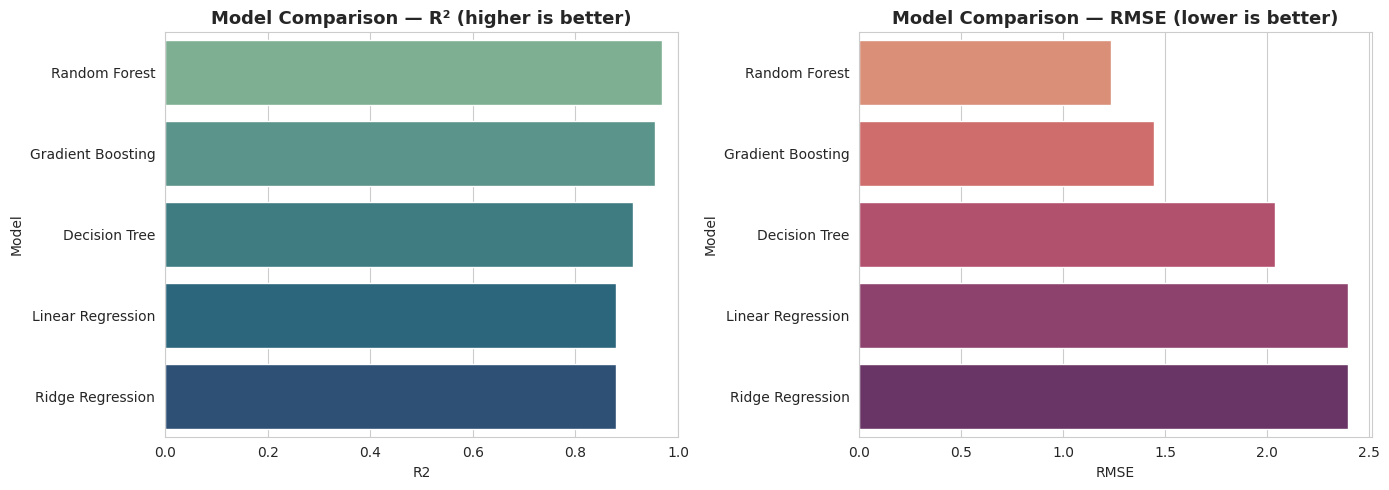

In [25]:
# Visual comparison of model performance metrics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x='R2', y='Model', palette='crest', ax=axes[0])
axes[0].set_title('Model Comparison — R² (higher is better)')
axes[0].set_xlim(0, 1)

sns.barplot(data=results_df, x='RMSE', y='Model', palette='flare', ax=axes[1])
axes[1].set_title('Model Comparison — RMSE (lower is better)')
plt.tight_layout()
plt.show()


Best performing model: Random Forest


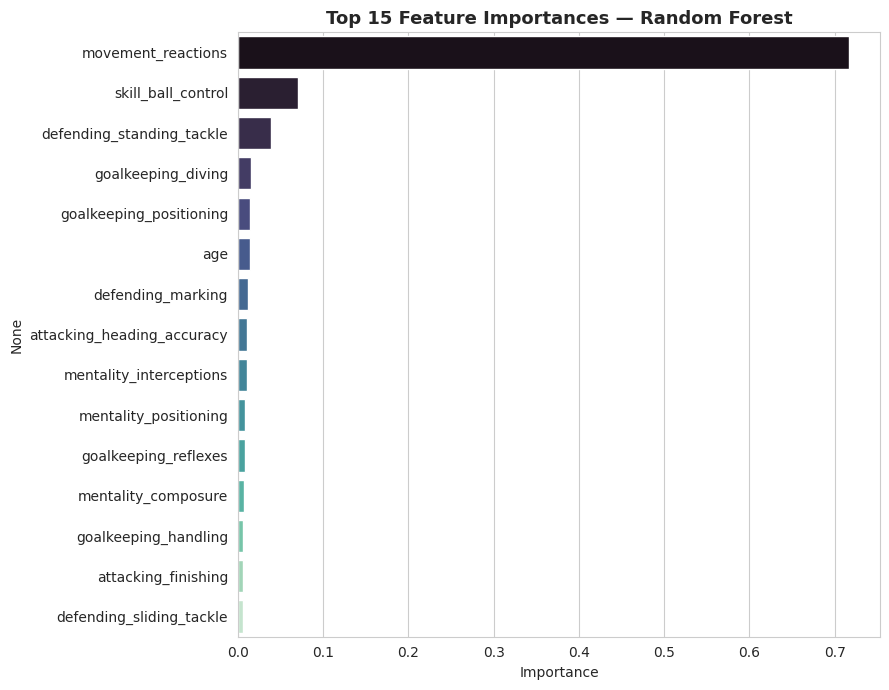

In [26]:
# Inspect the best model and determine which features matter most

best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f"Best performing model: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(x=importances.values, y=importances.index, palette='mako')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


In [27]:
# Save production artifacts so predictions can be recreated later

# Persist the best model and the scaler for production use
joblib.dump(best_model, 'best_overall_rating_model.pkl')
joblib.dump(scaler_model, 'feature_scaler.pkl')
print(f"Saved '{best_model_name}' to 'best_overall_rating_model.pkl'")


Saved 'Random Forest' to 'best_overall_rating_model.pkl'


<a id='9'></a>
## 9. Model Comparison Report

**Models evaluated:** Linear Regression, Ridge Regression, Decision Tree, Random Forest and Gradient
Boosting — all trained on the same 80/20 train-test split and the same standardised skill/physical
attributes, to predict a player's `overall` rating.

**Results summary** (see the `results_df` table and charts above):

- **Linear Regression / Ridge Regression** perform almost identically (R² ≈ 0.88), confirming the relationship
  between skill attributes and `overall` is mostly linear, but they leave noticeable error on the table because
  they cannot capture interaction effects between attributes (e.g. a finisher's value depends on *both*
  finishing *and* composure together, not on either alone).
- **Decision Tree** improves on the linear models (R² ≈ 0.91) by capturing some non-linear, rule-based
  patterns, but a single tree is prone to overfitting and is less stable than ensemble methods.
- **Gradient Boosting** performs strongly (R² ≈ 0.96), building trees sequentially to correct previous errors.
- **Random Forest** is the **best performing model** (R² ≈ 0.97, lowest MAE and RMSE), benefiting from
  averaging many de-correlated decision trees to reduce variance while still capturing non-linear
  relationships between attributes.

**Recommendation for production:** the **Random Forest Regressor** is the recommended model. It gives the
highest accuracy and the lowest error of all candidates tested, it is robust to outliers and irrelevant
features, it does not require heavy hyperparameter tuning to perform well, and — unlike Gradient Boosting — it
trains its trees independently, which makes it easier to parallelise and faster to retrain as new FIFA
versions/data become available. Its only drawback versus the linear models is reduced interpretability and a
somewhat heavier, slower-to-predict model object; both are acceptable trade-offs given the large accuracy
gain, and feature importances (see chart above) still give a useful, interpretable summary of which
attributes drive the prediction.

<a id='10'></a>
## 10. Challenges Faced — Report

**1. Structural (not random) missing data.** Roughly 2,000 rows were missing the six outfield attributes
(`pace`, `shooting`, ...) while a different, almost perfectly complementary set of rows was missing the six
goalkeeping attributes. Naively dropping rows or imputing with the column mean would have distorted both
groups. *Solution:* recognised this as a positional pattern (goalkeepers vs. outfield players) and filled both
groups with `0`, since the attribute genuinely does not apply rather than being unknown.

**2. Highly redundant columns.** The dataset includes 26 per-position rating columns (`ls`, `st`, `rw`, `cb`,
...) stored as strings like `"84+3"` (base rating + potential growth modifier). These duplicate information
already present in the granular skill columns and would have added noise and multicollinearity to both the
clustering and the regression model. *Solution:* dropped these columns and relied on the more granular,
purely-numeric skill attributes instead.

**3. Choosing the right target variable for clustering.** The project brief specifically warns against using
`overall` as a clustering feature, since it would dominate the distance calculation and effectively just
re-create the existing rating system rather than discover new structure. *Solution:* clustering was performed
only on the granular skill attributes, and `overall`/`potential` were reserved purely for downstream
discussion and validation.

**4. Selecting a meaningful number of clusters.** The silhouette score is maximised at `k = 2`, but this
simply rediscovers the trivial goalkeeper/outfield split and is not useful from a footballing perspective.
*Solution:* combined the elbow method with domain knowledge of the four real position groups (Goalkeeper,
Defender, Midfielder, Forward) to settle on `k = 4`, then validated the choice by cross-tabulating clusters
against the actual `position_group` labels.

**5. Small-sample noise in the age-vs-overall analysis.** A handful of ages (e.g. 41, 42) had only 1–4 players,
producing misleadingly extreme average ratings. *Solution:* restricted the age-trend analysis to ages with a
reasonably-sized sample (≥30 players) before interpreting the trend.

**6. Skewed financial variables.** `value_eur` and `wage_eur` are extremely right-skewed, dominated by a small
number of global superstars. *Solution:* used log-scaled axes for distribution plots and reported both mean
and median wage when comparing positions, since the mean alone can be misleading for skewed data.

**7. Avoiding data leakage in the regression model.** Attributes like `value_eur`, `wage_eur`, `release_clause_eur`
and `potential` are themselves *derived from* a player's overall quality, so including them as predictors of
`overall` would have leaked the answer into the features. *Solution:* the model uses only the underlying skill,
physical and reputation attributes as inputs, not other rating-derived financial fields.